# Fermi-surface nesting: where an instability will appear

A metal is unstable to whatever it can gain energy from, and the cheapest thing it can do
is open a gap on its own Fermi surface. That costs nothing in kinetic energy exactly where
one piece of the surface can be slid onto another, and the wavevector of the slide is what
the **nesting function** counts:

$$ N(\mathbf q) \;=\; \frac{1}{N_k}\sum_{\mathbf k}\, g(\mathbf k)\, g(\mathbf k + \mathbf q),
\qquad
g(\mathbf k) \;=\; g_s \sum_{n}\delta\!\left(\varepsilon_{n\mathbf k} - E_F\right). $$

$g(\mathbf k)$ is the density of states at a single $\mathbf k$, so it is a picture of the
Fermi surface drawn on the grid, and $N(\mathbf q)$ asks how much of that picture lands on
itself when it is translated by $\mathbf q$. Where the answer is large, a perturbation of
that wavevector connects many filled states to many empty ones for free: a phonon softens,
a charge-density wave opens a gap, or a spin spiral chooses that pitch.

It is the geometry of an instability rather than its strength. Nothing here knows how
strongly the electrons couple to the perturbation, so a peak says *where* to look and not
*whether* it wins.

| | |
|---|---|
| a half-filled hydrogen chain peaks at | **$q_3 = 0.5$**, exactly $2k_F$ |
| its peak reaches, of the maximum any crystal can have | **99.8%** |
| relaxing a spin spiral on the same chain lands at | **$q_3 = 0.500014$** |
| fcc aluminium's largest peak reaches | 45% of the same bound, at the smallest $q$ on the grid |

In [1]:
from pathlib import Path

from pypresso import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

chain = Calculator.from_file(CASES / "h-chain-nesting.in", PSEUDO, announce=False)
nest = chain.get_nesting(grid=(1, 1, 60))

where, peak = nest.peak()
print("peak at q = %s" % where)
print("N(q*)/N(0) = %.4f     D(E_F) = %.3f states/Ry" % (peak / nest.nesting[0],
                                                         nest.fermi_dos))

peak at q = [0.  0.  0.5]
N(q*)/N(0) = 0.9980     D(E_F) = 7.994 states/Ry


## Why one dimension nests perfectly

The chain is one hydrogen every 5 bohr, one electron per cell, and a band that holds two.
So it is **half filled**: states are occupied from $-k_F$ to $+k_F$ with $k_F = \pi/2c$, and
the Fermi surface is not a surface at all but the two points $\pm k_F$. One translation,
$q = 2k_F = \pi/c$, carries each onto the other, and in crystal coordinates that is exactly
$q_3 = \tfrac12$. Every point of the surface participates, which is what makes the peak
almost the largest it could be.

That bound is worth naming, because it decides how the plot must be read.
$\sum_k g(k)g(k+q) \le \sum_k g(k)^2$ for any $q$ whatsoever, so $N(0)$ is the maximum on
every crystal ever computed, and it says nothing about any of them. The question is always
how close some **other** wavevector gets to it, which is why the peak reported above skips
the origin.

In three dimensions nothing of the sort can happen. A spherical Fermi surface slid by
$\mathbf q$ meets its own translate only along a ring, so the overlap is negligible beside
the surface itself: $N(q)$ falls off as $1/q$ and cuts off at $2k_F$, where two spheres of
radius $k_F$ stop touching. In a crystal that tail is folded back into the zone by the
reciprocal lattice and several folded copies overlap at almost every $\mathbf q$, so what is
left is a featureless plateau. Aluminium is the case: a Fermi surface very close to a
free-electron sphere, and no wavevector at which it maps onto itself.

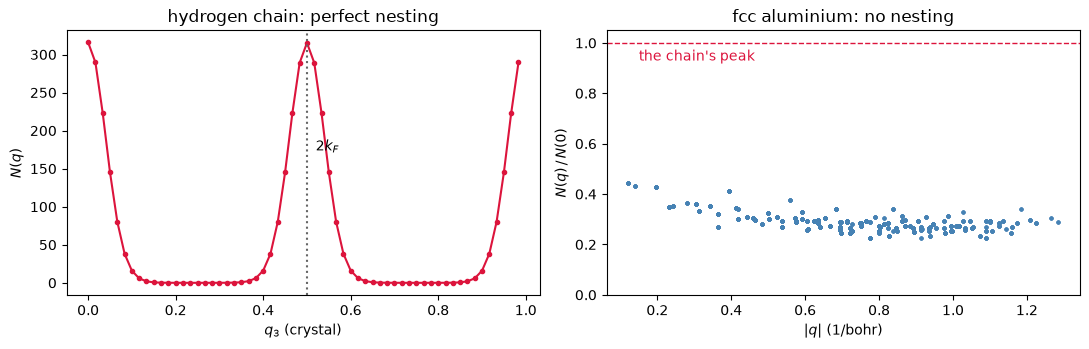

In [2]:
import numpy as np
import matplotlib.pyplot as plt

al = Calculator.from_file(CASES / "al-metal.in", PSEUDO, announce=False)
metal = al.get_nesting(grid=(12, 12, 12))
q = np.linalg.norm(al.system.cell.k_to_cartesian(
    metal.qpoints - np.rint(metal.qpoints)), axis=1) * al.system.cell.tpiba

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.6))
a.plot(*nest.along(2), "o-", ms=3, color="crimson")
a.axvline(0.5, ls=":", color="0.4")
a.text(0.52, 0.55 * peak, r"$2k_F$")
a.set(xlabel="$q_3$ (crystal)", ylabel="$N(q)$", title="hydrogen chain: perfect nesting")

b.plot(q[1:], metal.nesting[1:] / metal.nesting[0], ".", ms=4, color="steelblue")
b.axhline(peak / nest.nesting[0], ls="--", lw=1, color="crimson")
b.text(0.15, 0.93, "the chain's peak", color="crimson")
b.set(xlabel="$|q|$ (1/bohr)", ylabel="$N(q)\\,/\\,N(0)$", ylim=(0, 1.05),
      title="fcc aluminium: no nesting")
fig.tight_layout()

Aluminium's points scatter about the free-electron curve and nothing rises above it.
Its largest value away from $\Gamma$ is simply the first grid point, on the $1/q$ tail that
every metal has; there is no wavevector at which its Fermi sphere maps onto itself, and
aluminium correspondingly has no charge-density wave and no magnetic order.

## The prediction, tested against a completely different calculation

The chain's peak is a claim: a perturbation of pitch $q_3 = 0.5$ should win. The cheapest
one available to a hydrogen chain is magnetic, so the test is to give the same chain a spin
spiral, start it at the wrong pitch, and let the **total energy** decide where it goes. That
calculation shares nothing with this one. It is a magnet rather than a paramagnet, and what
it follows downhill is $dE/d\mathbf q$ rather than any property of a Fermi surface.

In [3]:
spiral = Calculator.from_text(
    (CASES / "h-chain-spiral.in").read_text()
    .replace("ecutwfc = 25.0", "ecutwfc = 40.0")
    .replace("spiral_q(3) = 0.25", "spiral_q(3) = 0.30"),
    PSEUDO, announce=False, max_iterations=300)
relaxed = spiral.get_spiral_relaxation(free=(0, 0, 1), nstep=20)

print("nesting predicts q3 = %.4f" % where[2])
print("the spiral relaxes to q3 = %.6f  (from 0.30, in %d runs)"
      % (relaxed.wavevector[2], relaxed.nsteps))

nesting predicts q3 = 0.5000
the spiral relaxes to q3 = 0.500014  (from 0.30, in 6 runs)


The two agree to the resolution the grid of the first one can offer, and the second
one had no way of knowing the answer: it was started at $0.30$ and walked. This is the
pairing that makes the nesting function worth computing rather than merely plotting. It is
cheap, it needs no magnetism, and it says which pitch to try; the expensive calculation then
confirms it.

The same logic is what connects nesting to phonons. A Kohn anomaly is a dip in a phonon
branch at $2k_F$, and the wavevectors where a lattice will distort are the wavevectors where
$N(\mathbf q)$ is large. Chromium's spin-density wave, the charge-density waves of the
layered dichalcogenides and the dimerization of a one-dimensional chain are all read off the
same picture.

One practical note. $g(\mathbf k)$ is a delta function on a surface, so the k-grid is the
convergence parameter of the whole quantity and it is worth far more than the band count. A
grid that is too coarse does not report a noisy peak; it reports a smooth one in the wrong
place, or none at all.

---

*Refused, with the reason in each case: a run with no Fermi level (fixed occupations), a
constrained `tot_magnetization`, which gives each spin channel a level of its own, and a
spin spiral, since the quantity is a statement about the state a spiral grows out of. The
validation, including the free-electron closed form and the unfolding of a symmetry-reduced
k-set, lives in `tests/unit/test_nesting_machinery.py` and
`tests/regression/test_nesting.py`.*